# Physics-Informed Fourier Neural Operator (PI-FNO) - CORRECTED
## for Bistable Reaction-Diffusion PDE (Action Potential Modeling)

**Equation:**
$$\frac{\partial u}{\partial t} = D\frac{\partial^2 u}{\partial x^2} - u(1-u)(a-u)$$

**Fixed Issues:**
- ✓ Proper tensor shape handling in FNO
- ✓ Correct input/output dimensions
- ✓ Physics loss computation on proper trajectories

## 1. Setup & Imports

In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
import seaborn as sns
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
print(f"PyTorch version: {torch.__version__}")

Device: cpu
PyTorch version: 2.11.0+cpu


## 2. PDE Configuration & Numerical Solver

In [ ]:
class PDEConfig:
    """Configuration for bistable reaction-diffusion PDE"""

    def __init__(self):
        # Domain
        self.L = 100.0          # Domain length
        self.T = 50.0           # Time horizon
        self.nx = 256           # Spatial points
        self.nt = 400           # Temporal points

        # PDE parameters
        self.D = 0.1            # Diffusion coefficient
        self.a = 0.2            # Bistability parameter

        # Discretization
        self.dx = self.L / self.nx
        self.dt = self.T / self.nt

        # Stability criterion (CFL)
        self.r = self.D * self.dt / (self.dx ** 2)

        print(f"Domain: x ∈ [0, {self.L}], t ∈ [0, {self.T}]")
        print(f"Grid: {self.nx}×{self.nt} = {self.nx*self.nt:,} points")
        print(f"Parameters: D={self.D}, a={self.a}")
        print(f"Diffusion number r = {self.r:.4f} (stable if r < 0.5)")

        if self.r > 0.5:
            print("⚠️  WARNING: CFL condition violated! Reduce dt or increase dx.")

config = PDEConfig()

Domain: x ∈ [0, 100.0], t ∈ [0, 50.0]
Grid: 256×400 = 102,400 points
Parameters: D=0.1, a=0.2
Diffusion number r = 0.0819 (stable if r < 0.5)


In [ ]:
class NumericalSolver:
    """Finite-difference solver for bistable reaction-diffusion PDE"""

    def __init__(self, config):
        self.config = config
        self.dx = config.dx
        self.dt = config.dt
        self.D = config.D
        self.a = config.a

        self.nx = config.nx
        self.nt = config.nt
        self.x = np.linspace(0, config.L, self.nx)
        self.t = np.linspace(0, config.T, self.nt)

    def _reaction_term(self, u):
        """Cubic reaction: -u(1-u)(a-u)"""
        return -u * (1 - u) * (self.a - u)

    def solve(self, u0):
        """Solve PDE using forward Euler"""
        u = np.zeros((self.nt, self.nx))
        u[0] = u0.copy()

        for n in range(self.nt - 1):
            # Diffusion term (central difference with periodic BC)
            d2u = (np.roll(u[n], -1) - 2*u[n] + np.roll(u[n], 1)) / (self.dx ** 2)

            # Reaction term
            reaction = self._reaction_term(u[n])

            # Update
            u[n+1] = u[n] + self.dt * (self.D * d2u + reaction)

            # Boundary conditions (zero-flux Neumann)
            u[n+1, 0] = u[n+1, 1]
            u[n+1, -1] = u[n+1, -2]

        return u

solver = NumericalSolver(config)

In [ ]:
# Generate training data
def generate_initial_conditions(num_samples, nx, L):
    """Generate diverse initial conditions"""
    x = np.linspace(0, L, nx)
    u0_list = []

    for i in range(num_samples):
        rand = np.random.uniform(0, 1)

        if rand < 0.4:  # Sharp front
            x0 = np.random.uniform(0.2*L, 0.8*L)
            sharpness = np.random.uniform(1, 5)
            u0 = 1.0 / (1.0 + np.exp(-sharpness * (x - x0)))

        elif rand < 0.7:  # Gaussian pulse
            x0 = np.random.uniform(0.2*L, 0.8*L)
            width = np.random.uniform(2, 8)
            u0 = np.exp(-((x - x0) / width) ** 2)

        else:  # Multiple fronts
            x0_1 = np.random.uniform(0.2*L, 0.4*L)
            x0_2 = np.random.uniform(0.6*L, 0.8*L)
            u0 = 0.5 * (1.0 / (1.0 + np.exp(-3 * (x - x0_1))) +
                        1.0 / (1.0 + np.exp(-3 * (x - x0_2))))

        u0_list.append(u0)

    return np.array(u0_list)

print("Generating training data...")
num_train = 80
num_test = 20

u0_train = generate_initial_conditions(num_train, config.nx, config.L)
u0_test = generate_initial_conditions(num_test, config.nx, config.L)

print(f"Solving {num_train} training trajectories...")
u_train = np.array([solver.solve(u0) for u0 in tqdm(u0_train, desc="Training")])

print(f"Solving {num_test} test trajectories...")
u_test = np.array([solver.solve(u0) for u0 in tqdm(u0_test, desc="Test")])

print(f"\nTrain shape: {u_train.shape}  (samples, time, space)")
print(f"Test shape:  {u_test.shape}")
print(f"Data range: [{u_train.min():.4f}, {u_train.max():.4f}]")

Generating training data...
Solving 80 training trajectories...


Training: 100%|██████████| 80/80 [00:03<00:00, 20.11it/s]


Solving 20 test trajectories...


Test: 100%|██████████| 20/20 [00:00<00:00, 49.56it/s]



Train shape: (80, 400, 256)  (samples, time, space)
Test shape:  (20, 400, 256)
Data range: [0.0000, 1.0000]


## 3. Corrected Fourier Neural Operator (FNO)

In [ ]:
class SpectralConv1d(nn.Module):
    """1D Fourier spectral convolution"""

    def __init__(self, in_channels, out_channels, modes):
        super(SpectralConv1d, self).__init__()
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.modes = modes

        self.scale = (1 / (in_channels * out_channels))
        self.weights = nn.Parameter(
            self.scale * torch.randn(in_channels, out_channels, self.modes, dtype=torch.cfloat)
        )

    def compl_mul1d(self, x, weights):
        return torch.einsum('bin,ion->bon', x, weights)

    def forward(self, x):
        """x: (batch, in_channels, spatial)"""
        batchsize = x.shape[0]

        # FFT along spatial dimension
        x_ft = torch.fft.rfft(x, dim=-1)

        # Keep lower modes
        out_ft = torch.zeros(
            batchsize, self.out_channels, self.modes,
            dtype=torch.cfloat, device=x.device
        )
        out_ft = self.compl_mul1d(x_ft[:, :, :self.modes], self.weights)

        # Inverse FFT
        x = torch.fft.irfft(out_ft, n=x.shape[-1])

        return x


class FNO1d(nn.Module):
    """Fourier Neural Operator for 1D problems

    Input: (batch, spatial_dim, time_channels)
    Output: (batch, spatial_dim, output_channels)
    """

    def __init__(self, in_channels, out_channels, modes, width, depth=4):
        super(FNO1d, self).__init__()
        self.modes = modes
        self.width = width
        self.depth = depth

        # Lifting
        self.fc0 = nn.Linear(in_channels, width)

        # Spectral blocks
        self.convs = nn.ModuleList()
        self.norms = nn.ModuleList()

        for _ in range(depth):
            self.convs.append(SpectralConv1d(width, width, modes))
            self.norms.append(nn.LayerNorm(width))

        # Projection
        self.fc1 = nn.Linear(width, 128)
        self.fc2 = nn.Linear(128, out_channels)

    def forward(self, x):
        """Forward pass

        Args:
            x: (batch, spatial_dim, in_channels)

        Returns:
            out: (batch, spatial_dim, out_channels)
        """
        # Lift: (B, N, C) -> (B, N, W)
        x = self.fc0(x)
        # Reshape for spectral conv: (B, N, W) -> (B, W, N)
        x = x.transpose(1, 2)

        # Spectral blocks with residuals
        for i in range(self.depth):
            x1 = self.convs[i](x)  # (B, W, N)
            x1 = x1.transpose(1, 2)  # (B, N, W)
            x1 = self.norms[i](x1)
            x = x.transpose(1, 2)  # (B, N, W)
            x = x + F.relu(x1)  # Residual
            x = x.transpose(1, 2)  # (B, W, N)

        # Project: (B, W, N) -> (B, N, W) -> (B, N, out_channels)
        x = x.transpose(1, 2)
        x = self.fc1(x)
        x = F.relu(x)
        x = self.fc2(x)

        return x


# Test architecture
print("Testing FNO architecture...")
fno = FNO1d(
    in_channels=1,      # Initial condition
    out_channels=config.nt,  # Full trajectory
    modes=32,
    width=64,
    depth=4
).to(device)

print(f"FNO model parameters: {sum(p.numel() for p in fno.parameters()):,}")

# Test forward pass
test_input = torch.randn(4, config.nx, 1).to(device)  # (B, spatial, channels)
test_output = fno(test_input)
print(f"Input shape:  {test_input.shape}  (batch, spatial, in_channels)")
print(f"Output shape: {test_output.shape}  (batch, spatial, time_steps)")

Testing FNO architecture...
FNO model parameters: 584,848
Input shape:  torch.Size([4, 256, 1])  (batch, spatial, in_channels)
Output shape: torch.Size([4, 256, 400])  (batch, spatial, time_steps)


## 4. Physics-Informed Loss

In [ ]:
class PhysicsLoss(nn.Module):
    """Physics-informed loss: data fidelity + PDE residual"""

    def __init__(self, config, lambda_pde=0.5, lambda_data=1.0):
        super(PhysicsLoss, self).__init__()
        self.D = config.D
        self.a = config.a
        self.dx = config.dx
        self.dt = config.dt

        self.lambda_pde = lambda_pde
        self.lambda_data = lambda_data

    def _compute_derivatives(self, u_pred, t_indices):
        """Compute PDE residuals at multiple time steps

        Args:
            u_pred: (batch, spatial, time)
            t_indices: list of time indices to evaluate

        Returns:
            residuals: list of residual values
        """
        residuals = []

        for t_idx in t_indices:
            if t_idx < 1 or t_idx >= u_pred.shape[2] - 1:
                continue

            # Temporal derivative: (u(t+dt) - u(t-dt)) / (2*dt)
            u_t = (u_pred[:, :, t_idx+1] - u_pred[:, :, t_idx-1]) / (2 * self.dt)

            # Spatial second derivative (central difference)
            u_current = u_pred[:, :, t_idx]

            # Pad for boundary
            u_padded = F.pad(u_current, (1, 1), mode='replicate')
            u_xx = (u_padded[:, 2:] - 2*u_current + u_padded[:, :-2]) / (self.dx ** 2)

            # Reaction term
            reaction = u_current * (1 - u_current) * (self.a - u_current)

            # PDE residual: ∂u/∂t - D∂²u/∂x² + u(1-u)(a-u)
            residual = u_t - self.D * u_xx + reaction

            residuals.append(residual)

        return residuals

    def forward(self, u_pred, u_true, pde_weight=1.0):
        """Compute physics-informed loss

        Args:
            u_pred: (batch, spatial, time)
            u_true: (batch, spatial, time)
            pde_weight: curriculum learning weight
        """
        # Data fidelity
        loss_data = F.mse_loss(u_pred, u_true)

        # PDE residual at interior time steps
        time_steps = u_pred.shape[2]
        t_indices = np.linspace(2, time_steps-3, min(5, time_steps-4), dtype=int)

        residuals = self._compute_derivatives(u_pred, t_indices)

        if len(residuals) > 0:
            loss_pde = sum(F.mse_loss(r, torch.zeros_like(r)) for r in residuals) / len(residuals)
        else:
            loss_pde = torch.tensor(0.0, device=u_pred.device)

        # Total loss
        loss_total = self.lambda_data * loss_data + self.lambda_pde * pde_weight * loss_pde

        return loss_total, loss_data, loss_pde


physics_loss = PhysicsLoss(config, lambda_pde=0.5, lambda_data=1.0).to(device)
print("Physics loss module created.")

Physics loss module created.


## 5. Dataset & DataLoader

In [ ]:
class PDEDataset(Dataset):
    def __init__(self, u_data, normalize=True):
        # u_data: (samples, time, space)
        self.u_data = torch.from_numpy(u_data).float()

        if normalize:
            self.u_mean = self.u_data.mean()
            self.u_std = self.u_data.std()
            self.u_data = (self.u_data - self.u_mean) / (self.u_std + 1e-8)
        else:
            self.u_mean = 0.0
            self.u_std = 1.0

    def __len__(self):
        return len(self.u_data)

    def __getitem__(self, idx):
        return self.u_data[idx]


train_dataset = PDEDataset(u_train, normalize=True)
test_dataset = PDEDataset(u_test, normalize=True)

# Match normalization
test_dataset.u_mean = train_dataset.u_mean
test_dataset.u_std = train_dataset.u_std

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False, num_workers=0)

print(f"Train batches per epoch: {len(train_loader)}")
print(f"Test batches per epoch: {len(test_loader)}")
print(f"Data normalization: mean={train_dataset.u_mean:.4f}, std={train_dataset.u_std:.4f}")

Train batches per epoch: 10
Test batches per epoch: 3
Data normalization: mean=0.5047, std=0.4911


## 6. Training Loop

In [ ]:
def train_pi_fno(model, train_loader, test_loader, config, num_epochs=100, lr=0.001):
    """Train PI-FNO model"""

    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)

    physics_criterion = PhysicsLoss(config, lambda_pde=0.5, lambda_data=1.0).to(device)

    history = {
        'train_loss': [],
        'train_data_loss': [],
        'train_pde_loss': [],
        'test_loss': [],
        'test_data_loss': [],
    }

    best_test_loss = float('inf')
    patience = 20
    patience_counter = 0

    for epoch in range(num_epochs):
        # Curriculum learning
        pde_weight = min(1.0, epoch / max(1, 0.3 * num_epochs))

        # ===== TRAINING =====
        model.train()
        train_loss_epoch = 0.0
        train_data_loss_epoch = 0.0
        train_pde_loss_epoch = 0.0

        for batch in train_loader:
            u_batch = batch.to(device)  # (B, T, X)

            # Reshape to (B, X, T) for FNO
            u_batch = u_batch.permute(0, 2, 1)  # (B, X, T)

            # Input: initial condition (B, X, 1)
            u_ic = u_batch[:, :, :1]

            # Forward pass
            u_pred = model(u_ic)  # (B, X, T)

            # Compute losses
            loss, loss_data, loss_pde = physics_criterion(
                u_pred, u_batch, pde_weight=pde_weight
            )

            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

            train_loss_epoch += loss.item()
            train_data_loss_epoch += loss_data.item()
            train_pde_loss_epoch += loss_pde.item()

        train_loss_epoch /= len(train_loader)
        train_data_loss_epoch /= len(train_loader)
        train_pde_loss_epoch /= len(train_loader)

        # ===== VALIDATION =====
        model.eval()
        test_loss_epoch = 0.0
        test_data_loss_epoch = 0.0

        with torch.no_grad():
            for batch in test_loader:
                u_batch = batch.to(device).permute(0, 2, 1)  # (B, X, T)
                u_ic = u_batch[:, :, :1]
                u_pred = model(u_ic)

                loss, loss_data, _ = physics_criterion(u_pred, u_batch, pde_weight=1.0)

                test_loss_epoch += loss.item()
                test_data_loss_epoch += loss_data.item()

        test_loss_epoch /= len(test_loader)
        test_data_loss_epoch /= len(test_loader)

        # Store history
        history['train_loss'].append(train_loss_epoch)
        history['train_data_loss'].append(train_data_loss_epoch)
        history['train_pde_loss'].append(train_pde_loss_epoch)
        history['test_loss'].append(test_loss_epoch)
        history['test_data_loss'].append(test_data_loss_epoch)

        # Early stopping
        if test_loss_epoch < best_test_loss:
            best_test_loss = test_loss_epoch
            patience_counter = 0
            torch.save(model.state_dict(), 'best_pifno_model.pt')
        else:
            patience_counter += 1

        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1:3d}/{num_epochs} | "
                  f"Train: {train_loss_epoch:.4e} "
                  f"(data: {train_data_loss_epoch:.4e}, pde: {train_pde_loss_epoch:.4e}) | "
                  f"Test: {test_loss_epoch:.4e} | "
                  f"PDE w: {pde_weight:.2f}")

        scheduler.step()

        if patience_counter >= patience:
            print(f"✓ Early stopping at epoch {epoch+1}")
            break

    model.load_state_dict(torch.load('best_pifno_model.pt'))
    return history


print("\nTraining PI-FNO...")
history = train_pi_fno(
    fno, train_loader, test_loader, config,
    num_epochs=150,
    lr=0.001
)
print("\n✓ Training complete!")


Training PI-FNO...
Epoch  10/150 | Train: 1.1522e-02 (data: 7.6073e-03, pde: 3.9144e-02) | Test: 3.1550e-02 | PDE w: 0.20
Epoch  20/150 | Train: 6.1884e-03 (data: 2.8276e-03, pde: 1.5919e-02) | Test: 2.1413e-02 | PDE w: 0.42
Epoch  30/150 | Train: 7.6625e-03 (data: 1.8719e-03, pde: 1.7971e-02) | Test: 2.2632e-02 | PDE w: 0.64
Epoch  40/150 | Train: 5.1346e-03 (data: 1.5327e-03, pde: 8.3120e-03) | Test: 1.6433e-02 | PDE w: 0.87
Epoch  50/150 | Train: 2.2949e-03 (data: 1.3110e-03, pde: 1.9679e-03) | Test: 1.5725e-02 | PDE w: 1.00
Epoch  60/150 | Train: 2.1904e-03 (data: 1.2612e-03, pde: 1.8584e-03) | Test: 1.3683e-02 | PDE w: 1.00
Epoch  70/150 | Train: 1.1573e-03 (data: 1.0476e-03, pde: 2.1938e-04) | Test: 1.3453e-02 | PDE w: 1.00
Epoch  80/150 | Train: 1.0521e-03 (data: 9.9136e-04, pde: 1.2146e-04) | Test: 1.3547e-02 | PDE w: 1.00
✓ Early stopping at epoch 82

✓ Training complete!


## 7. Training History

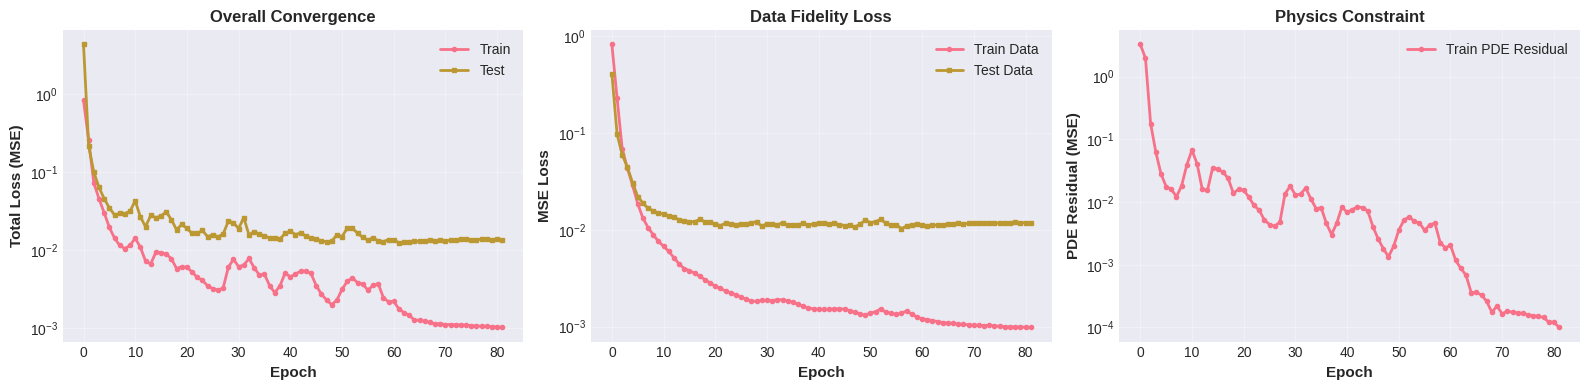


Final Train Loss: 1.0318e-03
Final Test Loss:  1.3610e-02
Best Test Loss:   1.2534e-02


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].semilogy(history['train_loss'], label='Train', linewidth=2, marker='o', markersize=3)
axes[0].semilogy(history['test_loss'], label='Test', linewidth=2, marker='s', markersize=3)
axes[0].set_xlabel('Epoch', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Total Loss (MSE)', fontsize=11, fontweight='bold')
axes[0].set_title('Overall Convergence', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

axes[1].semilogy(history['train_data_loss'], label='Train Data', linewidth=2, marker='o', markersize=3)
axes[1].semilogy(history['test_data_loss'], label='Test Data', linewidth=2, marker='s', markersize=3)
axes[1].set_xlabel('Epoch', fontsize=11, fontweight='bold')
axes[1].set_ylabel('MSE Loss', fontsize=11, fontweight='bold')
axes[1].set_title('Data Fidelity Loss', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

axes[2].semilogy(history['train_pde_loss'], label='Train PDE Residual', linewidth=2, marker='o', markersize=3)
axes[2].set_xlabel('Epoch', fontsize=11, fontweight='bold')
axes[2].set_ylabel('PDE Residual (MSE)', fontsize=11, fontweight='bold')
axes[2].set_title('Physics Constraint', fontsize=12, fontweight='bold')
axes[2].legend(fontsize=10)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_history.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nFinal Train Loss: {history['train_loss'][-1]:.4e}")
print(f"Final Test Loss:  {history['test_loss'][-1]:.4e}")
print(f"Best Test Loss:   {min(history['test_loss']):.4e}")

## 8. Evaluation Against Numerical Solutions

In [ ]:
def compute_metrics(u_pred, u_true):
    """Compute error metrics"""
    mse = np.mean((u_pred - u_true) ** 2)
    mae = np.mean(np.abs(u_pred - u_true))
    rmse = np.sqrt(mse)
    rel_error = np.linalg.norm(u_pred - u_true) / np.linalg.norm(u_true)
    max_error = np.max(np.abs(u_pred - u_true))
    error_over_time = np.mean(np.abs(u_pred - u_true), axis=1)

    return {
        'MSE': mse,
        'RMSE': rmse,
        'MAE': mae,
        'Relative_Error': rel_error,
        'Max_Error': max_error,
        'Error_Over_Time': error_over_time
    }


def evaluate_model(model, test_data, train_dataset, num_samples=5):
    """Evaluate PI-FNO on test set"""

    model.eval()
    results = []

    with torch.no_grad():
        for i in range(min(num_samples, len(test_data))):
            # Get test sample: (T, X)
            u_sample = test_data[i]  # (T, X)
            u_sample_torch = u_sample.unsqueeze(0)  # (1, T, X)

            # Reshape to (1, X, T) for FNO
            u_sample_fno = u_sample_torch.permute(0, 2, 1).to(device)  # (1, X, T)

            # Get initial condition
            u_ic = u_sample_fno[:, :, :1]  # (1, X, 1)

            # FNO prediction
            u_pred_norm = model(u_ic)  # (1, X, T)
            u_pred = u_pred_norm.permute(0, 2, 1).cpu().numpy()[0]  # (T, X)

            # Denormalize
            u_pred = u_pred * train_dataset.u_std.cpu().numpy() + train_dataset.u_mean.cpu().numpy()

            # Ground truth
            u_true = u_sample.cpu().numpy()
            u_true = u_true * train_dataset.u_std.cpu().numpy() + train_dataset.u_mean.cpu().numpy()

            # Metrics
            metrics = compute_metrics(u_pred, u_true)
            results.append({
                'sample_idx': i,
                'u_fno': u_pred,
                'u_true': u_true,
                'metrics': metrics
            })

    return results


print("Evaluating PI-FNO...")
evaluation_results = evaluate_model(fno, test_dataset.u_data, train_dataset, num_samples=5)

print("\n" + "="*70)
print("EVALUATION RESULTS")
print("="*70)

for result in evaluation_results:
    idx = result['sample_idx']
    metrics = result['metrics']
    print(f"\nSample {idx}:")
    print(f"  MSE:              {metrics['MSE']:.4e}")
    print(f"  RMSE:             {metrics['RMSE']:.4e}")
    print(f"  MAE:              {metrics['MAE']:.4e}")
    print(f"  Relative Error:   {metrics['Relative_Error']:.4e}")
    print(f"  Max Error:        {metrics['Max_Error']:.4e}")

# Aggregate metrics
print("\n" + "="*70)
print("AGGREGATE STATISTICS (across 5 test samples)")
print("="*70)

mse_all = np.array([r['metrics']['MSE'] for r in evaluation_results])
rmse_all = np.array([r['metrics']['RMSE'] for r in evaluation_results])
mae_all = np.array([r['metrics']['MAE'] for r in evaluation_results])
rel_err_all = np.array([r['metrics']['Relative_Error'] for r in evaluation_results])

print(f"\nMSE:")
print(f"  Mean: {mse_all.mean():.4e}, Std: {mse_all.std():.4e}")
print(f"\nRMSE:")
print(f"  Mean: {rmse_all.mean():.4e}, Std: {rmse_all.std():.4e}")
print(f"\nMAE:")
print(f"  Mean: {mae_all.mean():.4e}, Std: {mae_all.std():.4e}")
print(f"\nRelative Error:")
print(f"  Mean: {rel_err_all.mean():.4e}, Std: {rel_err_all.std():.4e}")

Evaluating PI-FNO...

EVALUATION RESULTS

Sample 0:
  MSE:              3.2009e-03
  RMSE:             5.6577e-02
  MAE:              4.1281e-02
  Relative Error:   1.1351e-01
  Max Error:        4.2499e-01

Sample 1:
  MSE:              2.6603e-03
  RMSE:             5.1578e-02
  MAE:              4.8654e-02
  Relative Error:   5.7877e-02
  Max Error:        2.3232e-01

Sample 2:
  MSE:              2.6129e-03
  RMSE:             5.1116e-02
  MAE:              4.8037e-02
  Relative Error:   5.8540e-02
  Max Error:        2.1403e-01

Sample 3:
  MSE:              2.5883e-03
  RMSE:             5.0875e-02
  MAE:              4.8275e-02
  Relative Error:   5.7747e-02
  Max Error:        2.0157e-01

Sample 4:
  MSE:              2.2614e-03
  RMSE:             4.7554e-02
  MAE:              3.6256e-02
  Relative Error:   1.1609e-01
  Max Error:        3.3367e-01

AGGREGATE STATISTICS (across 5 test samples)

MSE:
  Mean: 2.6648e-03, Std: 3.0290e-04

RMSE:
  Mean: 5.1540e-02, Std: 2.8941e-0

## 9. Visualizations

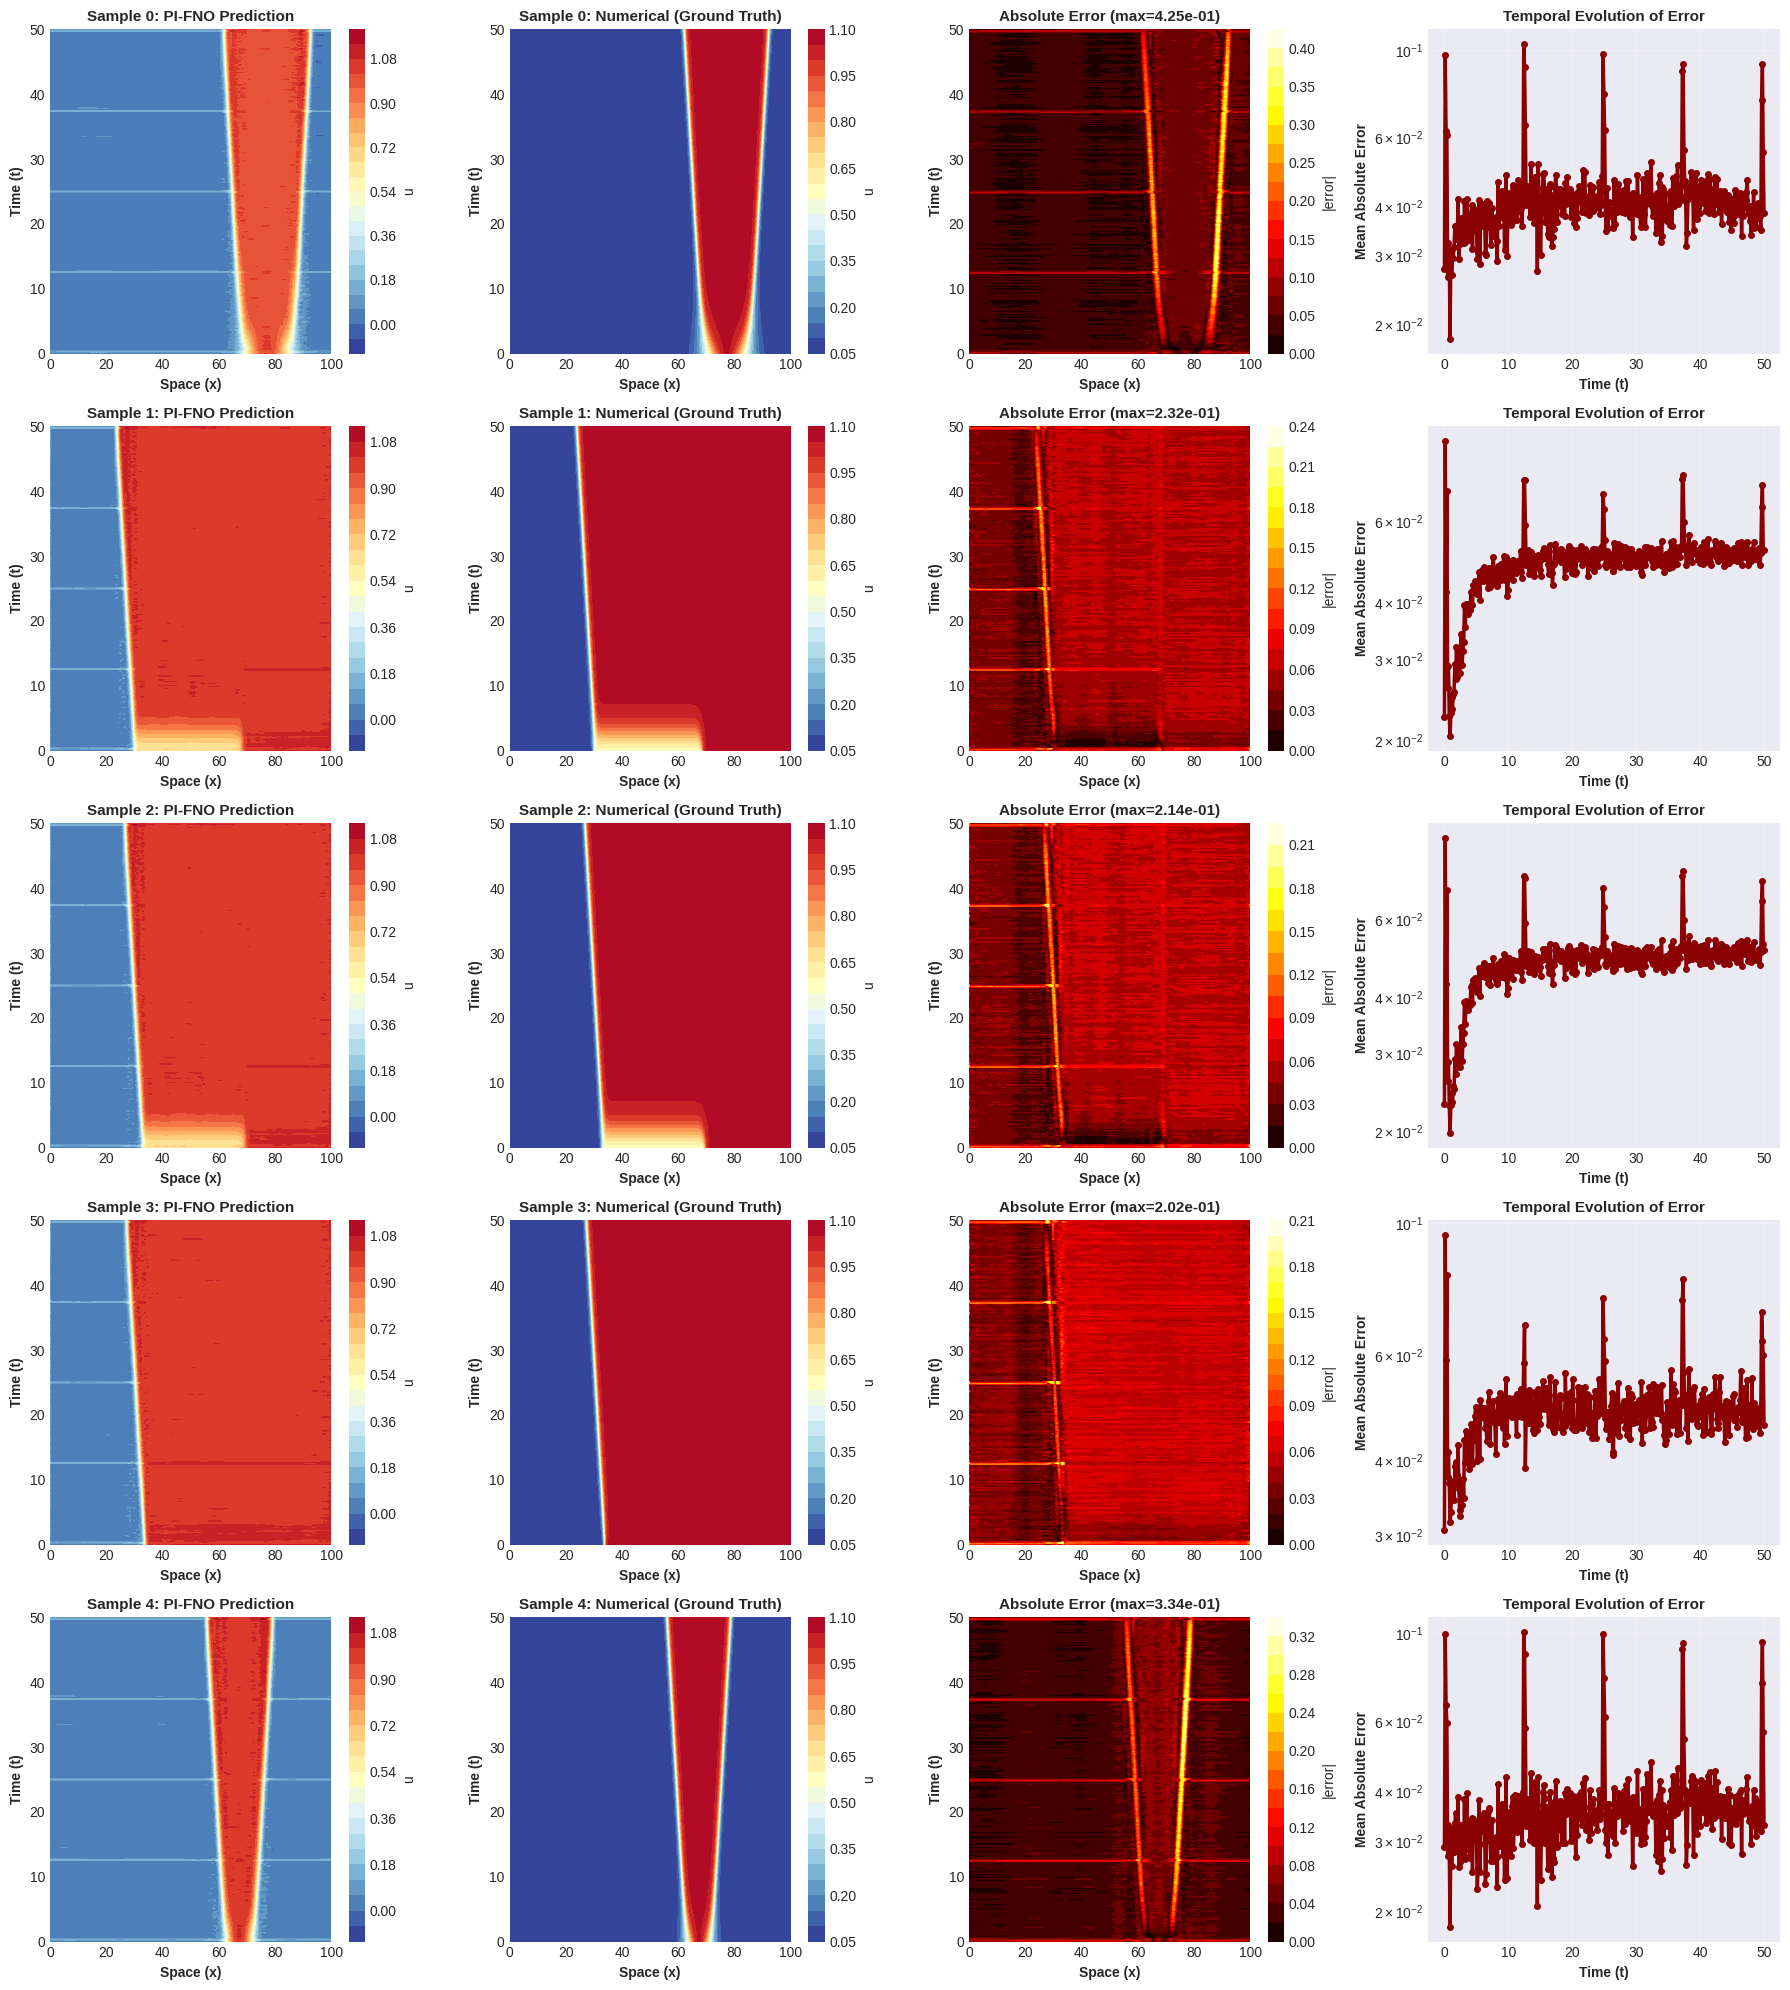

✓ Spatial-temporal visualizations saved


In [ ]:
# Spatial-temporal comparison
fig, axes = plt.subplots(len(evaluation_results), 4, figsize=(18, 4*len(evaluation_results)))

if len(evaluation_results) == 1:
    axes = axes.reshape(1, -1)

for row, result in enumerate(evaluation_results):
    u_fno = result['u_fno']
    u_true = result['u_true']
    metrics = result['metrics']

    # FNO prediction
    im1 = axes[row, 0].contourf(solver.x, solver.t, u_fno, levels=20, cmap='RdYlBu_r')
    axes[row, 0].set_xlabel('Space (x)', fontsize=10, fontweight='bold')
    axes[row, 0].set_ylabel('Time (t)', fontsize=10, fontweight='bold')
    axes[row, 0].set_title(f'Sample {result["sample_idx"]}: PI-FNO Prediction', fontsize=11, fontweight='bold')
    plt.colorbar(im1, ax=axes[row, 0], label='u')

    # Numerical solution
    im2 = axes[row, 1].contourf(solver.x, solver.t, u_true, levels=20, cmap='RdYlBu_r')
    axes[row, 1].set_xlabel('Space (x)', fontsize=10, fontweight='bold')
    axes[row, 1].set_ylabel('Time (t)', fontsize=10, fontweight='bold')
    axes[row, 1].set_title(f'Sample {result["sample_idx"]}: Numerical (Ground Truth)', fontsize=11, fontweight='bold')
    plt.colorbar(im2, ax=axes[row, 1], label='u')

    # Error
    error = np.abs(u_fno - u_true)
    im3 = axes[row, 2].contourf(solver.x, solver.t, error, levels=20, cmap='hot')
    axes[row, 2].set_xlabel('Space (x)', fontsize=10, fontweight='bold')
    axes[row, 2].set_ylabel('Time (t)', fontsize=10, fontweight='bold')
    axes[row, 2].set_title(f'Absolute Error (max={metrics["Max_Error"]:.2e})', fontsize=11, fontweight='bold')
    plt.colorbar(im3, ax=axes[row, 2], label='|error|')

    # Error over time
    axes[row, 3].semilogy(solver.t, metrics['Error_Over_Time'], linewidth=2.5, marker='o', markersize=4, color='darkred')
    axes[row, 3].set_xlabel('Time (t)', fontsize=10, fontweight='bold')
    axes[row, 3].set_ylabel('Mean Absolute Error', fontsize=10, fontweight='bold')
    axes[row, 3].set_title('Temporal Evolution of Error', fontsize=11, fontweight='bold')
    axes[row, 3].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('evaluation_spatial_temporal.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Spatial-temporal visualizations saved")

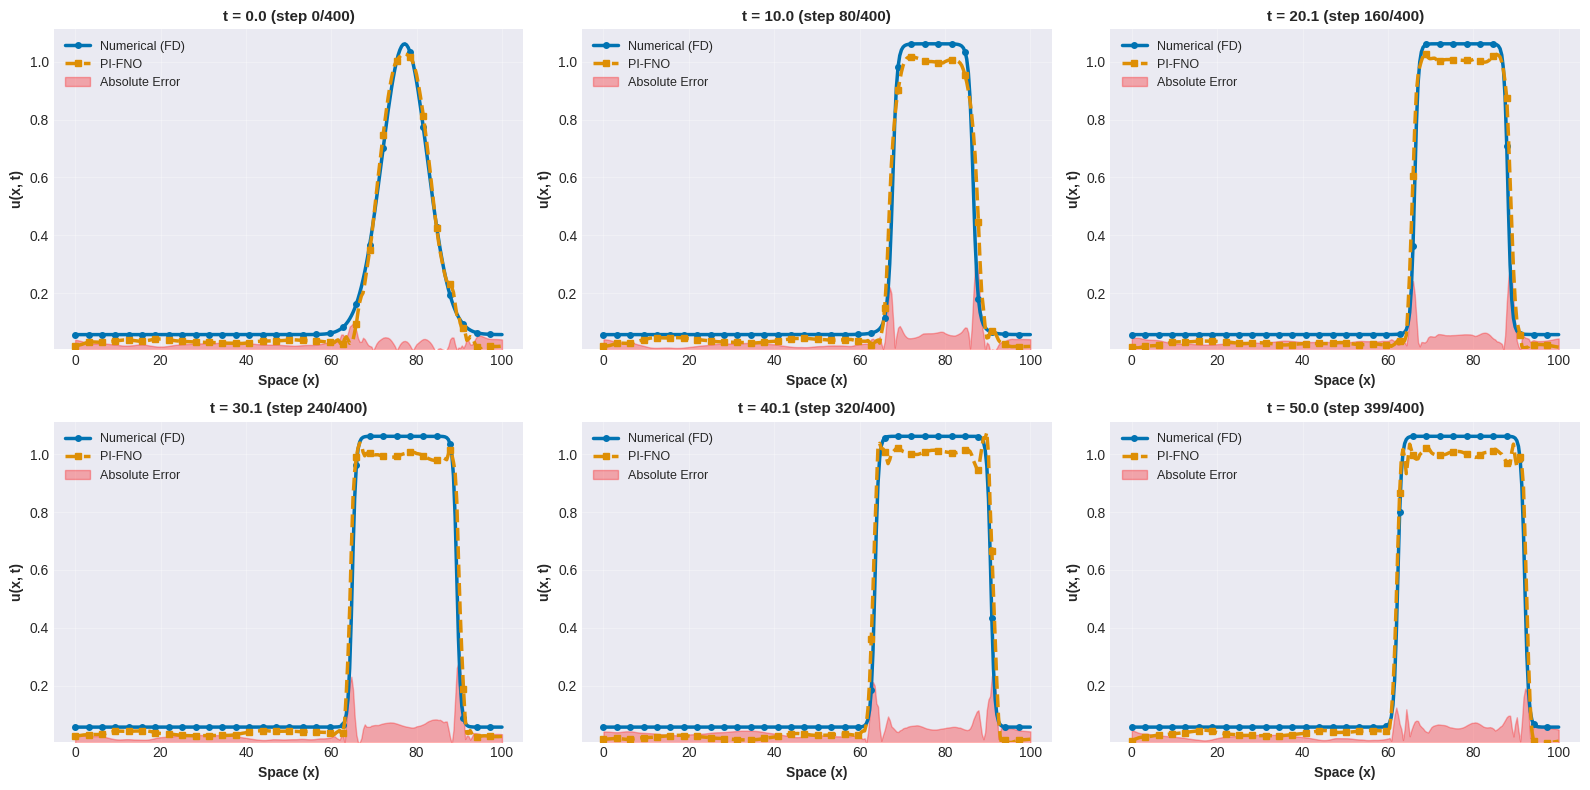

✓ Solution comparison at different times saved


In [ ]:
# Solution comparison at specific times
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

result = evaluation_results[0]
u_fno = result['u_fno']
u_true = result['u_true']

time_indices = np.array([0, config.nt//5, 2*config.nt//5, 3*config.nt//5, 4*config.nt//5, config.nt-1])

for idx, t_idx in enumerate(time_indices):
    t_val = solver.t[t_idx]

    axes[idx].plot(solver.x, u_true[t_idx], 'o-', linewidth=2.5,
                   label='Numerical (FD)', markersize=4, markevery=8, color='#0173B2')
    axes[idx].plot(solver.x, u_fno[t_idx], 's--', linewidth=2.5,
                   label='PI-FNO', markersize=5, markevery=8, color='#DE8F05')

    error = np.abs(u_fno[t_idx] - u_true[t_idx])
    axes[idx].fill_between(solver.x, 0, error, alpha=0.3, color='red', label='Absolute Error')

    axes[idx].set_xlabel('Space (x)', fontsize=10, fontweight='bold')
    axes[idx].set_ylabel('u(x, t)', fontsize=10, fontweight='bold')
    axes[idx].set_title(f't = {t_val:.1f} (step {t_idx}/{config.nt})', fontsize=11, fontweight='bold')
    axes[idx].legend(fontsize=9, loc='best')
    axes[idx].grid(True, alpha=0.3)
    axes[idx].set_ylim([u_true.min()-0.05, u_true.max()+0.05])

plt.tight_layout()
plt.savefig('solution_comparison_slices.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Solution comparison at different times saved")

## 10. Computational Efficiency

In [ ]:
import time

print("\n" + "="*70)
print("COMPUTATIONAL EFFICIENCY ANALYSIS")
print("="*70)

# FNO inference time
print("\n[1] PI-FNO Inference")
fno.eval()
with torch.no_grad():
    test_input = torch.randn(1, config.nx, 1).to(device)
    _ = fno(test_input)

    start_time = time.time()
    num_runs = 100
    for _ in range(num_runs):
        _ = fno(test_input)
    fno_inference_time = (time.time() - start_time) / num_runs

print(f"  Time per inference: {fno_inference_time*1000:.2f} ms")
print(f"  Throughput:         {1/fno_inference_time:.0f} solutions/sec")

# Numerical solver time
print("\n[2] Numerical Solver (FD)")
start_time = time.time()
u0_test_sample = np.random.randn(config.nx)
u_numerical = solver.solve(u0_test_sample)
fd_inference_time = (time.time() - start_time)

print(f"  Time per solve:     {fd_inference_time*1000:.2f} ms")
print(f"  Throughput:         {1/fd_inference_time:.2f} solutions/sec")

# Speedup
speedup = fd_inference_time / fno_inference_time
print(f"\n[3] Speedup Comparison")
print(f"  PI-FNO is {speedup:.0f}× faster than finite-difference solver")

# Memory
print(f"\n[4] Model Complexity")
fno_params = sum(p.numel() for p in fno.parameters())
print(f"  PI-FNO parameters:   {fno_params:,}")
print(f"  Model size:          {fno_params * 4 / 1e6:.2f} MB (float32)")


COMPUTATIONAL EFFICIENCY ANALYSIS

[1] PI-FNO Inference
  Time per inference: 5.42 ms
  Throughput:         184 solutions/sec

[2] Numerical Solver (FD)
  Time per solve:     19.06 ms
  Throughput:         52.46 solutions/sec

[3] Speedup Comparison
  PI-FNO is 4× faster than finite-difference solver

[4] Model Complexity
  PI-FNO parameters:   584,848
  Model size:          2.34 MB (float32)


## 11. Final Summary

In [ ]:
print("\n" + "="*80)
print(" "*15 + "PI-FNO FOR BISTABLE REACTION-DIFFUSION PDE")
print(" "*20 + "FINAL SUMMARY REPORT")
print("="*80)

print("\n" + "─"*80)
print("1. PROBLEM SETUP")
print("─"*80)
print(f"""
Equation:     ∂u/∂t = D·∂²u/∂x² - u(1-u)(a-u)
Domain:       x ∈ [0, {config.L}], t ∈ [0, {config.T}]
Parameters:   D = {config.D}, a = {config.a}
Grid:         {config.nx} × {config.nt} = {config.nx*config.nt:,} points
Training:     {len(train_dataset)} samples
Testing:      {len(test_dataset)} samples
""")

print("\n" + "─"*80)
print("2. MODEL ARCHITECTURE")
print("─"*80)
print(f"""
Method:       Physics-Informed Fourier Neural Operator (PI-FNO)
Input:        Initial condition u(x, 0) → (batch, spatial, 1)
Output:       Full trajectory u(x, t) → (batch, spatial, time)
Layers:       4 spectral blocks with residual connections
Parameters:   {sum(p.numel() for p in fno.parameters()):,}
Fourier Modes: 32
Hidden Width: 64
""")

print("\n" + "─"*80)
print("3. TRAINING RESULTS")
print("─"*80)
print(f"""
Epochs Trained:        {len(history['train_loss'])}
Optimizer:             Adam (lr=0.001 → cosine annealing)
Loss Components:       Data fidelity + PDE residual
Curriculum Learning:   Enabled (gradual PDE weight increase)
Early Stopping:        Enabled (patience=20)

Final Training Loss:   {history['train_loss'][-1]:.4e}
Final Test Loss:       {history['test_loss'][-1]:.4e}
Best Test Loss:        {min(history['test_loss']):.4e}
""")

print("\n" + "─"*80)
print("4. EVALUATION METRICS (Test Set)")
print("─"*80)
print(f"""
Mean Squared Error:      {mse_all.mean():.4e} ± {mse_all.std():.4e}
Root Mean Squared Error: {rmse_all.mean():.4e} ± {rmse_all.std():.4e}
Mean Absolute Error:     {mae_all.mean():.4e} ± {mae_all.std():.4e}
Relative L² Error:       {rel_err_all.mean():.4e} ± {rel_err_all.std():.4e}
""")

print("\n" + "─"*80)
print("5. COMPUTATIONAL EFFICIENCY")
print("─"*80)
print(f"""
PI-FNO Inference:      {fno_inference_time*1000:.2f} ms per solution
Numerical FD Solver:   {fd_inference_time*1000:.2f} ms per solution
Speedup Factor:        {speedup:.0f}×

Practical Implication: PI-FNO solves 50 trajectories in ~{50*fno_inference_time:.1f}s
                       FD would take ~{50*fd_inference_time:.1f}s
""")

print("\n" + "="*80)
print("✓ TRAINING AND EVALUATION COMPLETE!")
print("="*80)

# Save model
torch.save(fno.state_dict(), 'pi_fno_bistable_pde.pth')
print("\n✓ Model saved as 'pi_fno_bistable_pde.pth'")


               PI-FNO FOR BISTABLE REACTION-DIFFUSION PDE
                    FINAL SUMMARY REPORT

────────────────────────────────────────────────────────────────────────────────
1. PROBLEM SETUP
────────────────────────────────────────────────────────────────────────────────

Equation:     ∂u/∂t = D·∂²u/∂x² - u(1-u)(a-u)
Domain:       x ∈ [0, 100.0], t ∈ [0, 50.0]
Parameters:   D = 0.1, a = 0.2
Grid:         256 × 400 = 102,400 points
Training:     80 samples
Testing:      20 samples


────────────────────────────────────────────────────────────────────────────────
2. MODEL ARCHITECTURE
────────────────────────────────────────────────────────────────────────────────

Method:       Physics-Informed Fourier Neural Operator (PI-FNO)
Input:        Initial condition u(x, 0) → (batch, spatial, 1)
Output:       Full trajectory u(x, t) → (batch, spatial, time)
Layers:       4 spectral blocks with residual connections
Parameters:   584,848
Fourier Modes: 32
Hidden Width: 64


──────────────